## IMPORTS

In [1]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm  
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings 


In [2]:
data = pd.read_csv("../powerconsumption.csv")

Primero eliminar el patron repetitivo matematicamente (Veremos la diferencia entre el time stemp actual - el de ayer) 

Datetime
2017-01-01 00:00:00    34055.69620
2017-01-01 00:10:00    29814.68354
2017-01-01 00:20:00    29128.10127
2017-01-01 00:30:00    28228.86076
2017-01-01 00:40:00    27335.69620
Name: target, dtype: float64


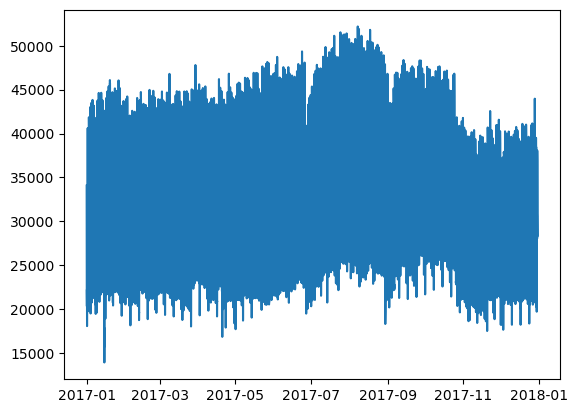

In [3]:
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")
data['target'] = data["PowerConsumption_Zone1"]
ready = data["target"].dropna()


print(ready.head())
plt.plot(ready)
plt.show()

In [4]:
ADF_result = adfuller(ready)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -32.121278534626
p-value: 0.0


In [5]:
TESTTIMESTEPS = 1008 #A week

train = ready.iloc[:-TESTTIMESTEPS]
test  = ready.iloc[-TESTTIMESTEPS:]

print(f'Tamaño train : {len(train):,} horas  ({len(train)/24:.0f} días)')
print(f'Tamaño test  : {len(test):,} horas  ({len(test)/24:.0f} días)')
print(f'Train: {train.index.min()} → {train.index.max()}')
print(f'Test : {test.index.min()}  → {test.index.max()}')

Tamaño train : 51,408 horas  (2142 días)
Tamaño test  : 1,008 horas  (42 días)
Train: 2017-01-01 00:00:00 → 2017-12-23 23:50:00
Test : 2017-12-24 00:00:00  → 2017-12-30 23:50:00


In [6]:
ps = range(0, 6, 1) #From 0 to 3 with steps of 1
qs = range(0, 3, 1) #From 0 to 3 with steps of 1

order_list = list(product(ps, qs))
print(order_list) #16 possible combinations which means 16 different ARMA models.

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2), (4, 0), (4, 1), (4, 2), (5, 0), (5, 1), (5, 2)]


In [7]:
warnings.filterwarnings("ignore")
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm(order_list): 
      try:
          model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False) 
      except:
        continue

      aic = model.aic
      results.append([order, aic]) 

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']

    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

result_df = optimize_ARMA(train, order_list)
result_df


100%|██████████| 18/18 [04:16<00:00, 14.27s/it]


,"(p,q)",AIC
0,"(2, 2)",7.744423e+05
1,"(3, 2)",7.744427e+05
2,"(4, 2)",7.744437e+05
3,"(5, 2)",7.744485e+05
4,"(5, 0)",7.744753e+05
5,"(5, 1)",7.744805e+05
6,"(4, 1)",7.744849e+05
7,"(3, 1)",7.745419e+05
8,"(4, 0)",7.745966e+05
9,"(2, 1)",7.750210e+05


Mejor orden segun AIC: p=2, q=2
ARMA (2,0,2)  MAE: 18,241 | RMSE: 20,266
Naive Seasonal      MAE: 1,192 | RMSE: 1,735


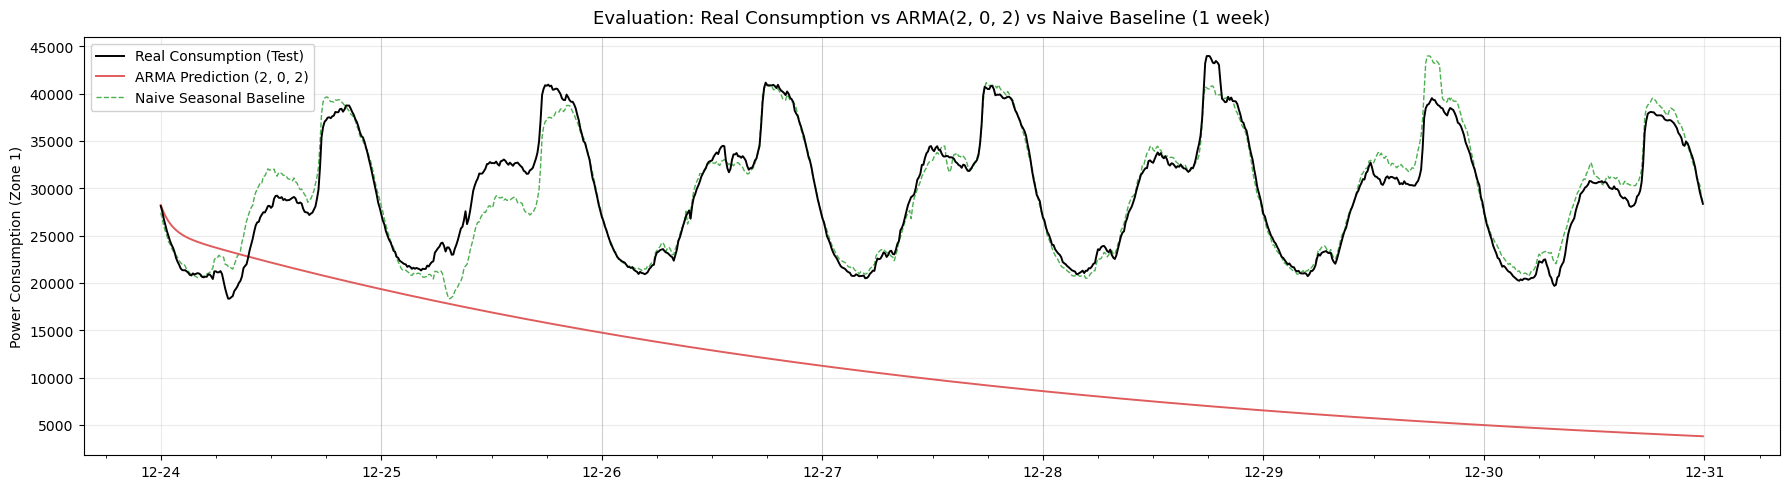

In [ ]:
best_order = result_df.iloc[0]['(p,q)']
print(f'Mejor orden segun AIC: p={best_order[0]}, q={best_order[1]}')

order = list(best_order)
modelo_final = SARIMAX(train, order=(order[0], 0, order[1]), simple_differencing=False)
resultado = modelo_final.fit(disp=False)

pasos_futuros = TESTTIMESTEPS  # 1008 pasos = 1 semana
prediccion_arma = resultado.forecast(steps=pasos_futuros)

prediccion_arma.index = test.index  

consumo_real_test = data['PowerConsumption_Zone1'].loc[test.index]

fechas_ayer_naive = consumo_real_test.index - pd.Timedelta(days=1)
naive_baseline = data['PowerConsumption_Zone1'].loc[fechas_ayer_naive].values
naive_serie = pd.Series(
    naive_baseline,
    index=consumo_real_test.index,
    name='Naive Seasonal Baseline'
)

mae_arma  = (consumo_real_test - prediccion_arma).abs().mean()
mae_naive = (consumo_real_test - naive_serie).abs().mean()
rmse_arma  = ((consumo_real_test - prediccion_arma)**2).mean()**0.5
rmse_naive = ((consumo_real_test - naive_serie)**2).mean()**0.5

print(f'ARMA ({order[0]},0,{order[1]})  MAE: {mae_arma:,.0f} | RMSE: {rmse_arma:,.0f}')
print(f'Naive Seasonal      MAE: {mae_naive:,.0f} | RMSE: {rmse_naive:,.0f}')

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(consumo_real_test.index, consumo_real_test.values,
        color='black', linewidth=1.4, label='Real Consumption (Test)', zorder=3)

ax.plot(prediccion_arma.index, prediccion_arma.values,
        color='#E05C5C', linewidth=1.4,
        label=f'ARMA Prediction ({order[0]}, 0, {order[1]})', zorder=2)

ax.plot(naive_serie.index, naive_serie.values,
        color='#4CAF50', linewidth=1.0, linestyle='--',
        label='Naive Seasonal Baseline', zorder=1)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

ax.set_title(f'Evaluation: Real Consumption vs ARMA({order[0]}, 0, {order[1]}) vs Naive Baseline (1 week)',
             fontsize=13, pad=10)
ax.set_ylabel('Power Consumption (Zone 1)')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25)

start_day = consumo_real_test.index[0].normalize() + pd.Timedelta(days=1)
end_day   = consumo_real_test.index[-1]
for day_tick in pd.date_range(start_day, end_day, freq='D'):
    ax.axvline(day_tick, color='gray', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()


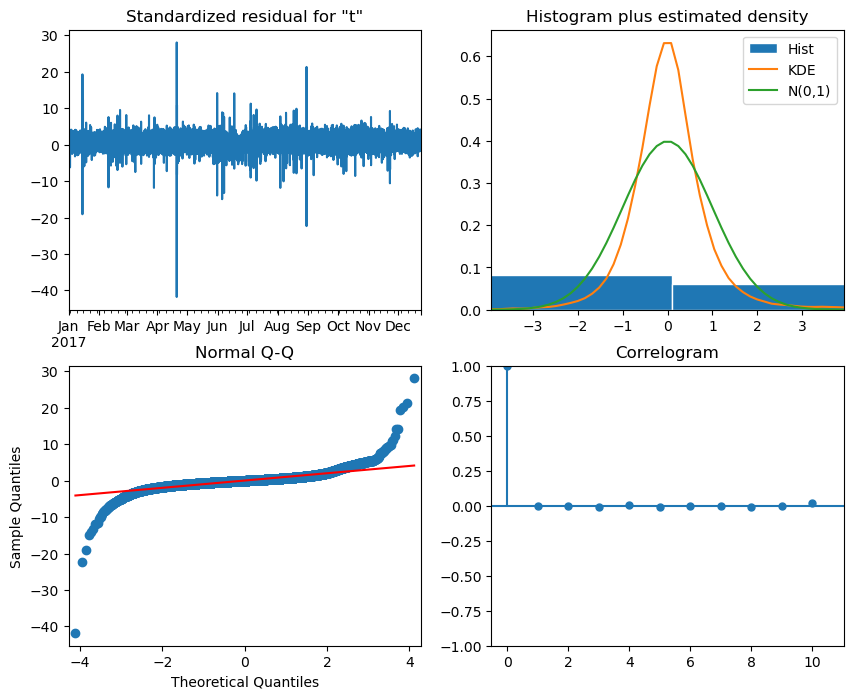

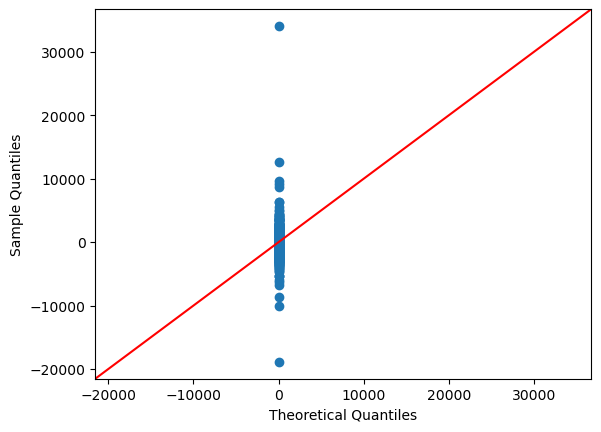

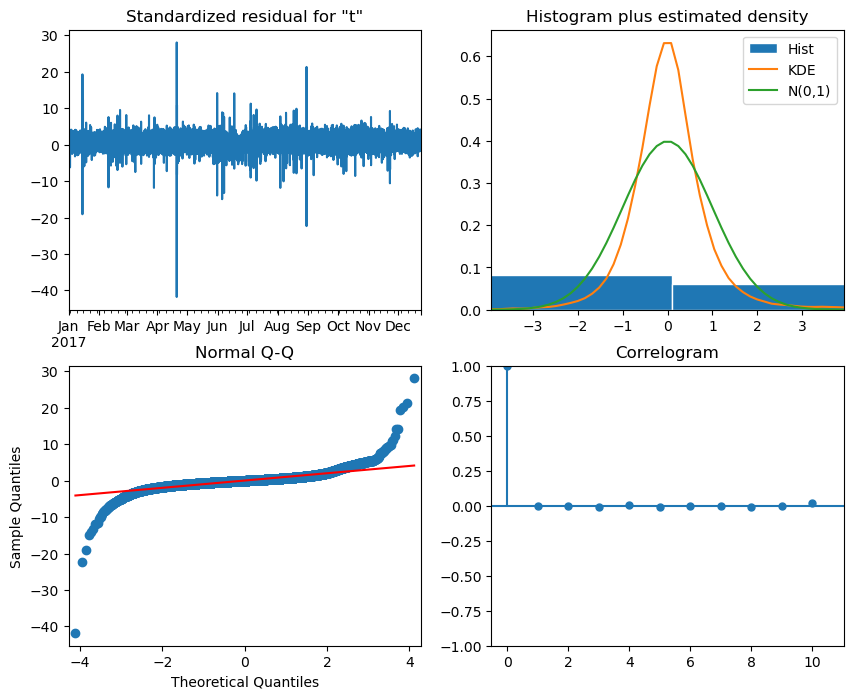

In [13]:
from statsmodels.graphics.gofplots import qqplot
residuals = resultado.resid
qqplot(residuals, line='45')
resultado.plot_diagnostics(figsize=(10, 8))

ARMA(2,0,2) aplicado sobre la serie colapsa hacia la media tras pocos pasos, ya que no tiene capacidad para modelar la estacionalidad diaria (período 144). El MAE/RMSE resultante es muy superior al Naive Baseline, lo que evidencia la necesidad de modelos que incorporen componentes estacionales (SARIMA) o diferenciación previa (ARIMA con naïve approach).

